# Problem Set 3 - Random Numbers

**Table of contents**<a id='toc0_'></a>    
- 1. [RNG Warm-up (Reproducibility Basics)](#toc1_)    
- 2. [Drawing from a Pareto distribution](#toc2_)    
- 3. [Unemployment](#toc3_)    
- 4. [Many workers: Unemployment](#toc4_)    
- 5. [Deterministic simulation with transition matrix](#toc5_)    
- 6. [Diversification: two correlated stocks](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. <a id='toc1_'></a>[RNG Warm-up (Reproducibility Basics)](#toc0_)

**Goal.** Create reproducible draws; understand *seed vs stream*.

- Create `rng = np.random.default_rng(2025)`.
- Draw 5 uniforms and 5 normals.
- Re-create the same sequence by constructing a **new** generator with the same seed.
- Show that **calling the same generator twice** advances the stream (different outputs).

In [2]:
# write your own code here
rng = np.random.default_rng(2025)
u1 = rng.random(5)
z1 = rng.standard_normal(5)

# Task: reproduce the first draws from a new generator with the same seed
# u2 = ...
# z2 = ...

# stream progression (same generator again)
u_next = rng.random(5)
z_next = rng.standard_normal(5)

In [3]:
import A1
A1.rng_warmup()

u1:            [0.99445781 0.38200974 0.82714801 0.83725528 0.97580901]
u2 (match u1): [0.99445781 0.38200974 0.82714801 0.83725528 0.97580901]
z1:            [ 0.7653914  -0.75970935  0.26699619  0.70178085  0.29212132]
z2 (match z1): [ 0.7653914  -0.75970935  0.26699619  0.70178085  0.29212132]

u_next (different): [0.38954302 0.23021956 0.16696115 0.15343643 0.9740917 ]
z_next (different): [-0.3924407  -0.67731696  2.93601077 -0.66462723  1.25746344]


## 2. <a id='toc2_'></a>[Drawing from a Pareto distribution](#toc0_)

**Goal.** Get familiar with drawing from a non-normal distribution and visualising its heavy tail.

The Pareto distribution is a classic model of "fat-tailed" data (wealth, city sizes, firm sizes). With shape parameter $b$ and minimum value $x_m=1$ the fraction of draws above $x$ is
$$P(X>x) = x^{-b},\qquad x\ge 1.$$

**Tasks.**
1. Draw `size=10_000` numbers from a Pareto distribution with shape `b=2.0` using a local generator. 

    *Hint:* `rng.pareto(b, size) + 1.0` gives the classic Pareto with $x_m=1$.

2. Plot a **histogram** of `log(draws)`.

3. Plot the **tail** (the empirical fraction of draws above $x$, $P(X>x)$) on **log-log axes**. For a Pareto it should look like a straight line.

In [4]:
# write your own code here

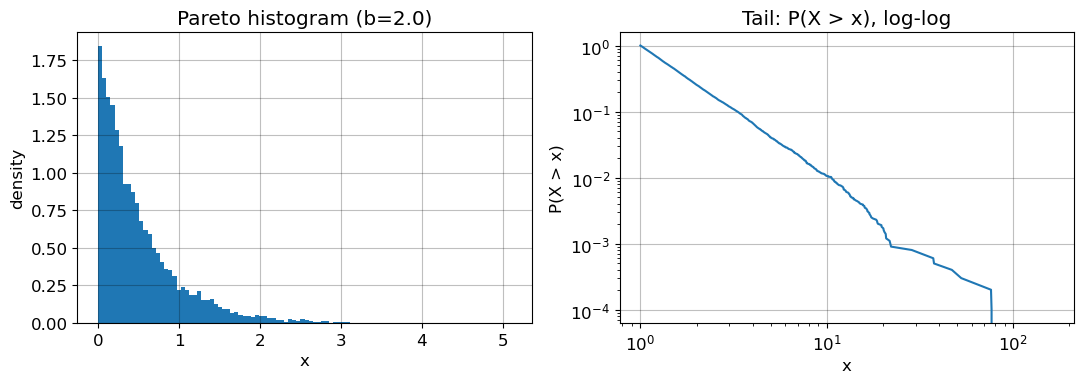

mean = 2.013, max = 164.3, share > 10 = 0.0106


In [5]:
import A2
A2.plot_pareto(b=2.0, size=10_000, seed=2026)

## 3. <a id='toc3_'></a>[Unemployment](#toc0_)

**Goal.** Simulate a single worker who is hit by random shocks each period:

- If **Employed** ($E$), a bad shock causes separation to **Unemployment** ($U$) with probability $s$.
- If **Unemployed** ($U$), a good shock leads to job finding back to $E$ with probability $f$.

Encode $0=E$, $1=U$ so that the average of the path is directly the unemployment share.

**Intuition.** Each period a worker is in one state. A *transition probability* tells you how likely it is to switch next period ($s$ is the job-separation rate, $f$ the job-finding rate). Simulating just means: draw a uniform $u\sim U[0,1]$ and compare it to the relevant probability to decide the next state.

**Task: Implement the following**

1. Pick inputs: horizon $T$, separation probability $s$, job-finding probability $f$, initial state $s_0\in\{0,1\}$ (encode $0=E$, $1=U$), and a seed.
2. For each period $t=0,\dots,T-1$, draw one uniform $\epsilon_t\sim U[0,1]$ and apply:
   - If in $E$: set next state to $U$ if $\epsilon_t<s$, else stay in $E$.
   - If in $U$: set next state to $E$ if $\epsilon_t<f$, else stay in $U$.
3. Store the whole path of length $T+1$ and report the share of time in $U$ (the mean, since $U=1$).

**Hints**
- Use $0=E$, $1=U$ so averages give unemployment directly.
- One fresh random draw per period.
- Start small ($T=20$) to print and check; then scale up.
- Set a seed for reproducibility while debugging.

In [6]:
s = 0.02
f = 0.30
s0 = 0
# write your own code here

In [7]:
import A3
A3.run(T=1_000, s=s, f=f, s0=s0, seed=2026)

First 10 shocks (uniforms): [0.179 0.64  0.467 0.371 0.355 0.791 0.905 0.177 0.653 0.298]
First 10 states (0=E,1=U):  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Share of time in U (single worker): 0.0579


## 4. <a id='toc4_'></a>[Many workers: Unemployment](#toc0_)

Simulate $N$ (e.g. 50,000) workers in parallel (one uniform draw per worker per period) and track the unemployment rate over time. With many workers the cross-sectional unemployment rate settles down close to the theoretical value $\pi_U^*=\frac{s}{s+f}$.

Plot the unemployment rate against time to see it settle down from the initial condition (all workers start employed) toward $\pi_U^*$. The early periods, before the rate has converged, are the **burn-in**: because every worker starts in the same state, this initial transition is not representative of the long-run (steady-state) behaviour and is typically discarded before computing a time average.

In [8]:
# write your own code here

First 10 unemployment rates: [0.     0.0202 0.0343 0.0431 0.0495 0.0528 0.0562 0.0586 0.06   0.0611]
Last 10 unemployment rates:  [0.0636 0.064  0.0622 0.0636 0.0647 0.0639 0.064  0.0629 0.0612 0.0623]
Average unemployment rate after burn-in (t>1000): 0.0625
Theoretical s/(s+f):         0.0625


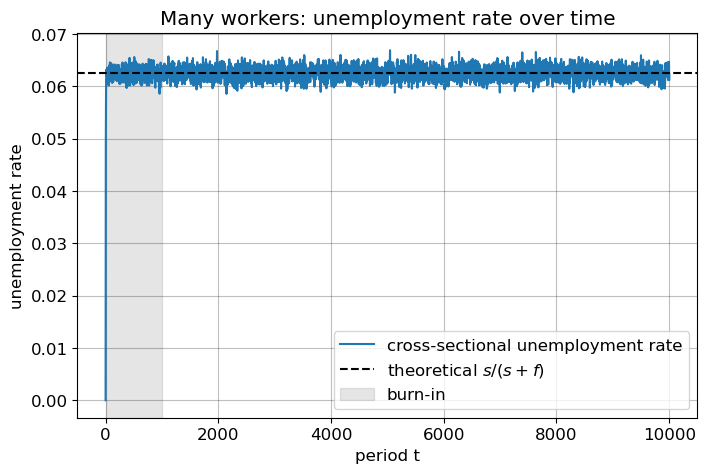

In [9]:
import A4
A4.run(T=10_000, N=50_000, s=s, f=f, s0=s0, seed=2026, burn_in=1_000)

## 5. <a id='toc5_'></a>[Deterministic simulation with transition matrix](#toc0_)

Now collect the two hazards into a transition matrix. Let $s\in(0,1)$ be the separation probability (E→U) and $f\in(0,1)$ the job-finding probability (U→E):
$$
P = \begin{pmatrix}
1-s & s\\
f & 1-f
\end{pmatrix}.
$$

**Matrix interpretation**
- States: `E=0` (employed), `U=1` (unemployed).
- Rows = current state, columns = next state.
- $P$ is **row-stochastic**: each row sums to 1 and all entries are in $[0,1]$.

Let $\pi_t=(\pi_{t,E},\pi_{t,U})$ be the **population distribution** at time $t$: a row vector giving the share of workers in each state, so $\pi_{t,E}+\pi_{t,U}=1$. 

$\pi_0$ is just this distribution at $t=0$ — e.g. $\pi_0=(1,0)$ means everyone starts employed.

**Your tasks**
1. Implement `make_P(s, f)` returning the matrix above and validate it (entries in $[0,1]$, rows sum to 1).
2. Use $P$ to run a **deterministic** simulation of the population shares: starting from $\pi_0$, iterate $\pi_{t+1}=\pi_t P$. No random numbers are involved. Check that the unemployment share converges to the **same** value as the stochastic simulation above and to the theoretical $\frac{s}{s+f}$.

In [10]:
def make_P(s, f):
    """Return a 2x2 row-stochastic transition matrix for E=0, U=1."""
    assert 0.0 <= s <= 1.0 and 0.0 <= f <= 1.0, "Probabilities must be in [0,1]."
    # TODO: implement
    P = np.array([[1.0, 0.0],
                  [0.0, 1.0]], dtype=float)
    return P

# write your own code here

In [11]:
import A5
A5.run(s=0.02, f=0.30, T=200, pi0=(1.0, 0.0))

P =
[[0.98 0.02]
 [0.3  0.7 ]]
First 10 unemployment shares: [0.     0.02   0.0336 0.0428 0.0491 0.0534 0.0563 0.0583 0.0596 0.0606]
Deterministic steady-state unemployment: 0.0625
Theoretical s/(s+f):                     0.0625


## 6. <a id='toc6_'></a>[Diversification: Two correlated stocks](#toc0_)

**Goal.** Use Monte Carlo simulation (as in lecture 6) to show the **value of diversification**: splitting your money across two imperfectly correlated stocks lowers risk without lowering the expected return.

**Setup.** Two stocks have the *same* expected annual return $\mu$ and the *same* volatility $\sigma$, but their returns are correlated with coefficient $\eta$. Their (random) annual returns are
$$r_A = \mu + \sigma z_1,\qquad r_B = \mu + \sigma\,(\eta\, z_1 + \sqrt{1-\eta^2}\, z_2),$$
where $z_1, z_2$ are independent standard normals. (This is a simple way to build two correlated normals from independent draws.) 

An equal-weighted portfolio earns $r_P = \tfrac12 r_A + \tfrac12 r_B$.

**Tasks.**
1. Write a function that, given a correlation $\eta$, simulates `n_worlds` draws of $(r_A, r_B)$, forms the equal-weighted portfolio, and returns the **standard deviation** of $r_P$ across worlds. Vectorize over worlds (no Python loop over draws).
2. Check that the portfolio's **mean** return is still $\approx \mu$, but its **standard deviation** is below the single-stock $\sigma$ (for $\eta < 1$).
3. Sweep $\eta$ from $-1$ to $1$ and plot the Monte Carlo portfolio volatility against $\eta$. Overlay the single-stock level $\sigma$.

**Hints.**
- Use one local generator `rng = np.random.default_rng(seed)`.
- Draw `z1 = rng.normal(size=n_worlds)` and `z2 = rng.normal(size=n_worlds)`.
- Suggested parameters: $\mu=0.08$, $\sigma=0.20$, `n_worlds = 100_000`.

In [12]:
mu = 0.08
sigma=0.20
n_worlds = 100_000

# write your own code here

single stock: mean=0.0800, std=0.2000
eta=-0.5: portfolio mean=0.0802, std=0.0999
eta=+0.0: portfolio mean=0.0801, std=0.1417
eta=+0.5: portfolio mean=0.0796, std=0.1732
eta=+1.0: portfolio mean=0.0801, std=0.1999


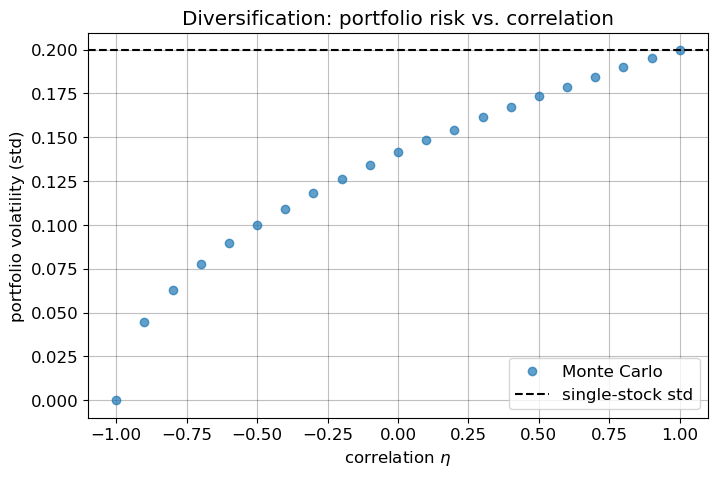

In [13]:
import A6
A6.run(mu=mu, sigma=sigma, n_worlds=n_worlds, seed=2026)